In [21]:
# CELL 1

from pathlib import Path
import json

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from api.process_ai.process.pipeline.process_configs import get_process_config
from api.process_ai.process.pipeline.orchestrator import (
    TrainParams,
    train_process_from_key,
)
from api.process_ai.process.core.inference import (
    load_process_artifacts,
    analyze_batch,
)

In [22]:
# CELL 2

def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "api").exists() and (p / "model").exists():
            return p
    raise FileNotFoundError("Could not find project root")

def to_abs_path(path_like: str | Path, project_root: Path) -> Path:
    p = Path(path_like)
    return p if p.is_absolute() else (project_root / p).resolve()

PROJECT_ROOT = find_project_root()

PROCESS_KEY = "warehouse"
cfg = get_process_config(PROCESS_KEY)
PROCESS_CODE = cfg.process_code

DATA_DIR = to_abs_path(cfg.data_dir, PROJECT_ROOT)
REGISTRY_DIR = to_abs_path(cfg.registry_dir, PROJECT_ROOT)
MODEL_DIR = to_abs_path(cfg.model_dir, PROJECT_ROOT)
REPORT_DIR = to_abs_path(cfg.report_dir, PROJECT_ROOT)

EVENTS_PATH = DATA_DIR / "events.csv"
MONITORING_DIR = REPORT_DIR / "monitoring"
MONITORING_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT  :", PROJECT_ROOT)
print("PROCESS_KEY   :", PROCESS_KEY)
print("PROCESS_CODE  :", PROCESS_CODE)
print("DATA_DIR      :", DATA_DIR)
print("REGISTRY_DIR  :", REGISTRY_DIR)
print("MODEL_DIR     :", MODEL_DIR)
print("REPORT_DIR    :", REPORT_DIR)
print("MONITORING_DIR:", MONITORING_DIR)

PROJECT_ROOT  : D:\logistics_AI
PROCESS_KEY   : warehouse
PROCESS_CODE  : WAREHOUSE_FULFILLMENT
DATA_DIR      : D:\logistics_AI\data\synth_optimal_3process_v1
REGISTRY_DIR  : D:\logistics_AI\data\synth_optimal_3process_v1\registry
MODEL_DIR     : D:\logistics_AI\model\process_models
REPORT_DIR    : D:\logistics_AI\reports\warehouse
MONITORING_DIR: D:\logistics_AI\reports\warehouse\monitoring


In [23]:
# CELL 3

mpl.rcParams.update(mpl.rcParamsDefault)
plt.style.use("default")

PRIMARY = "#1f4e79"
SECONDARY = "#5b9bd5"
ACCENT = "#9dc3e6"
GRID = "#d9d9d9"
TEXT = "#222222"

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.labelcolor"] = TEXT
plt.rcParams["xtick.color"] = TEXT
plt.rcParams["ytick.color"] = TEXT
plt.rcParams["text.color"] = TEXT
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 11

def pretty_step_label(x: str) -> str:
    x = str(x)
    x = x.replace("STEP_", "")
    parts = x.split("_", 1)
    if len(parts) == 2 and parts[0].isdigit():
        x = parts[1]
    x = x.replace("_", " ").title()
    return x[:28] + "..." if len(x) > 28 else x

def style_axes(ax, grid_axis="x"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")
    ax.grid(axis=grid_axis, color=GRID, linestyle="-", linewidth=0.8, alpha=0.7)
    ax.set_axisbelow(True)

def save_and_show(fig, path: Path):
    fig.tight_layout()
    fig.savefig(path, dpi=240, bbox_inches="tight", facecolor="white")
    plt.show()
    print("Saved:", path)

In [24]:
# CELL 4

events_df = pd.read_csv(EVENTS_PATH)
events_df = events_df[events_df["process_code"].astype(str) == PROCESS_CODE].copy()

events_df["start_time"] = pd.to_datetime(events_df["start_time"], errors="coerce")
events_df["end_time"] = pd.to_datetime(events_df["end_time"], errors="coerce")

events_df = events_df.dropna(subset=["start_time", "end_time"]).copy()
events_df["case_id"] = events_df["case_id"].astype(str)
events_df["month"] = events_df["start_time"].dt.to_period("M").astype(str)

print("events_df shape:", events_df.shape)
print("month range:", events_df["month"].min(), "->", events_df["month"].max())
display(events_df.head())

events_df shape: (276000, 6)
month range: 2025-04 -> 2025-07


,process_code,case_id,step_code,start_time,end_time,month
0,WAREHOUSE_FULFILLMENT,ORD_5260181590,STEP_001_ORDER_CONFIRMED,2025-06-28 13:45:50,2025-06-28 13:54:31,2025-06
1,WAREHOUSE_FULFILLMENT,ORD_5260181590,STEP_002_FRAUD_CHECK,2025-06-28 13:54:31,2025-06-28 14:04:02,2025-06
2,WAREHOUSE_FULFILLMENT,ORD_5260181590,STEP_003_PAYMENT_VERIFIED,2025-06-28 14:04:02,2025-06-28 15:19:11,2025-06
3,WAREHOUSE_FULFILLMENT,ORD_5260181590,STEP_004_INVENTORY_RESERVED,2025-06-28 15:19:11,2025-06-28 15:28:34,2025-06
4,WAREHOUSE_FULFILLMENT,ORD_5260181590,STEP_005_WAVE_PLANNED,2025-06-28 15:28:34,2025-06-28 15:41:37,2025-06


In [25]:
# CELL 5

artifacts = load_process_artifacts(
    process_code=PROCESS_CODE,
    model_root_dir=MODEL_DIR,
    registry_dir=REGISTRY_DIR,
)

print("Loaded artifacts for:", artifacts.process_code)
print("Number of step codes:", len(artifacts.step_codes))
print("Schema keys:", list(artifacts.schema.keys()))

Loaded artifacts for: WAREHOUSE_FULFILLMENT
Number of step codes: 23
Schema keys: ['step_codes', 'step_feature_cols', 'all_feature_cols']


In [26]:
# CELL 6

batch_out = analyze_batch(
    events_df,
    artifacts=artifacts,
    allow_unknown_steps=False,
    max_cases=None,
)

summary_payload = batch_out["summary"]

ok_rows = []
for r in batch_out["results"]:
    if not r.get("ok"):
        continue

    top1 = r["top_steps"][0] if r.get("top_steps") else {}

    ok_rows.append({
        "process_code": r.get("process_code"),
        "case_id": str(r.get("case_id")),
        "risk_score": r.get("risk_score"),
        "anomaly_score": r.get("raw_anomaly"),
        "overall_severity": str(r.get("overall_severity")).strip().upper(),
        "top_step_name": top1.get("step_code"),
        "top_step_duration_min": top1.get("duration_min"),
        "top_step_p95": top1.get("p95"),
        "top_step_deviation_p95": top1.get("deviation_factor"),
        "top_step_zscore": top1.get("z_score"),
        "top_step_severity": top1.get("severity"),
        "validation_warnings": r.get("validation_warnings"),
    })

results_df = pd.DataFrame(ok_rows).copy()

print("summary_payload:")
print(summary_payload)

print("\nresults_df shape:", results_df.shape)
display(results_df.head())

summary_payload:
{'process_code': 'WAREHOUSE_FULFILLMENT', 'cases_analyzed': 12000, 'cases_ok': 12000, 'avg_risk': 49.500083333333336, 'p95_risk': 94.04999999999927}

results_df shape: (12000, 12)


,process_code,case_id,risk_score,anomaly_score,overall_severity,top_step_name,top_step_duration_min,top_step_p95,top_step_deviation_p95,top_step_zscore,top_step_severity,validation_warnings
0,WAREHOUSE_FULFILLMENT,ORD_5260181590,78.0,0.432292,CRITICAL,STEP_011_PACKING_START,58.583,35.201,1.664,4.134,CRITICAL,[]
1,WAREHOUSE_FULFILLMENT,ORD_6723268656,36.0,0.397522,NORMAL,STEP_023_WAREHOUSE_CLOSEOUT,21.583,19.917,1.084,2.160,WATCHLIST,[]
2,WAREHOUSE_FULFILLMENT,ORD_6668364507,21.0,0.387890,NORMAL,STEP_009_SORTATION_COMPLETE,33.583,30.034,1.118,2.034,WATCHLIST,[]
3,WAREHOUSE_FULFILLMENT,ORD_1923969372,52.0,0.408687,CRITICAL,STEP_015_MANIFEST_CREATED,40.467,19.733,2.051,5.618,CRITICAL,[]
4,WAREHOUSE_FULFILLMENT,ORD_1636246770,54.0,0.410222,NORMAL,STEP_007_PICK_COMPLETE,28.717,25.067,1.146,2.435,WATCHLIST,[]


In [27]:
# CELL 7

case_month_df = (
    events_df.groupby("case_id", as_index=False)
    .agg(
        first_start_time=("start_time", "min"),
        event_rows=("case_id", "size"),
    )
)

case_month_df["case_id"] = case_month_df["case_id"].astype(str)
case_month_df["month"] = case_month_df["first_start_time"].dt.to_period("M").astype(str)

results_df = results_df.merge(
    case_month_df[["case_id", "month", "event_rows"]],
    on="case_id",
    how="left",
)

print("results_df shape after month merge:", results_df.shape)
display(results_df.head())

results_df shape after month merge: (12000, 14)


,process_code,case_id,risk_score,anomaly_score,overall_severity,top_step_name,top_step_duration_min,top_step_p95,top_step_deviation_p95,top_step_zscore,top_step_severity,validation_warnings,month,event_rows
0,WAREHOUSE_FULFILLMENT,ORD_5260181590,78.0,0.432292,CRITICAL,STEP_011_PACKING_START,58.583,35.201,1.664,4.134,CRITICAL,[],2025-06,23
1,WAREHOUSE_FULFILLMENT,ORD_6723268656,36.0,0.397522,NORMAL,STEP_023_WAREHOUSE_CLOSEOUT,21.583,19.917,1.084,2.160,WATCHLIST,[],2025-04,23
2,WAREHOUSE_FULFILLMENT,ORD_6668364507,21.0,0.387890,NORMAL,STEP_009_SORTATION_COMPLETE,33.583,30.034,1.118,2.034,WATCHLIST,[],2025-04,23
3,WAREHOUSE_FULFILLMENT,ORD_1923969372,52.0,0.408687,CRITICAL,STEP_015_MANIFEST_CREATED,40.467,19.733,2.051,5.618,CRITICAL,[],2025-05,23
4,WAREHOUSE_FULFILLMENT,ORD_1636246770,54.0,0.410222,NORMAL,STEP_007_PICK_COMPLETE,28.717,25.067,1.146,2.435,WATCHLIST,[],2025-05,23


In [28]:
# CELL 8

monitoring_summary_df = pd.DataFrame([{
    "process_code": PROCESS_CODE,
    "cases_analyzed": int(summary_payload["cases_analyzed"]),
    "cases_ok": int(summary_payload["cases_ok"]),
    "avg_risk": float(summary_payload["avg_risk"]),
    "p95_risk": float(summary_payload["p95_risk"]),
    "high_risk_cases_80plus": int((results_df["risk_score"] >= 80).sum()),
    "high_risk_rate_80plus": float((results_df["risk_score"] >= 80).mean() * 100),
    "critical_cases": int((results_df["overall_severity"] == "CRITICAL").sum()),
    "critical_rate": float((results_df["overall_severity"] == "CRITICAL").mean() * 100),
}])

display(monitoring_summary_df)

,process_code,cases_analyzed,cases_ok,avg_risk,p95_risk,high_risk_cases_80plus,high_risk_rate_80plus,critical_cases,critical_rate
0,WAREHOUSE_FULFILLMENT,12000,12000,49.500083,94.05,2400,20.0,2279,18.991667


In [29]:
# CELL 9

monthly_monitor_df = (
    results_df.groupby("month")
    .agg(
        case_count=("case_id", "count"),
        avg_risk=("risk_score", "mean"),
        p95_risk=("risk_score", lambda s: np.percentile(s, 95)),
        avg_anomaly=("anomaly_score", "mean"),
        high_risk_rate=("risk_score", lambda s: (s >= 80).mean() * 100),
        critical_rate=("overall_severity", lambda s: (s == "CRITICAL").mean() * 100),
    )
    .reset_index()
    .sort_values("month")
)

display(monthly_monitor_df)

,month,case_count,avg_risk,p95_risk,avg_anomaly,high_risk_rate,critical_rate
0,2025-04,3915,49.808174,94.0,0.413649,20.842912,19.412516
1,2025-05,4153,49.160366,95.0,0.412990,19.672526,18.709367
2,2025-06,3932,49.552136,94.0,0.413037,19.506612,18.870804


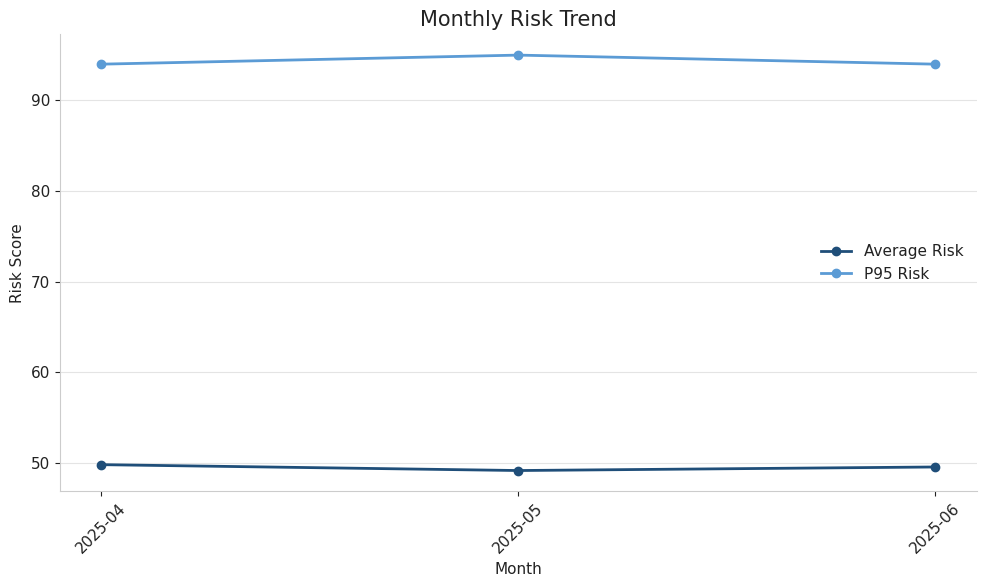

Saved: D:\logistics_AI\reports\warehouse\monitoring\warehouse_monthly_risk_trend.png


In [30]:
# CELL 10

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(monthly_monitor_df["month"], monthly_monitor_df["avg_risk"], marker="o", linewidth=2, color=PRIMARY, label="Average Risk")
ax.plot(monthly_monitor_df["month"], monthly_monitor_df["p95_risk"], marker="o", linewidth=2, color=SECONDARY, label="P95 Risk")

ax.set_title("Monthly Risk Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Risk Score")
style_axes(ax, grid_axis="y")
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False)

risk_trend_path = MONITORING_DIR / f"{PROCESS_KEY}_monthly_risk_trend.png"
save_and_show(fig, risk_trend_path)

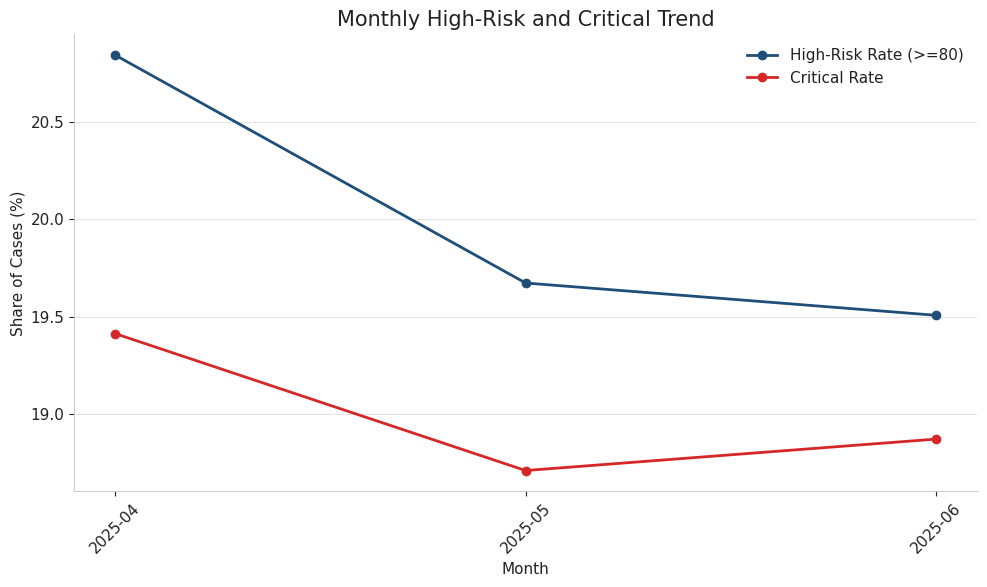

Saved: D:\logistics_AI\reports\warehouse\monitoring\warehouse_monthly_highrisk_critical_trend.png


In [31]:
# CELL 11

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(monthly_monitor_df["month"], monthly_monitor_df["high_risk_rate"], marker="o", linewidth=2, color=PRIMARY, label="High-Risk Rate (>=80)")
ax.plot(monthly_monitor_df["month"], monthly_monitor_df["critical_rate"], marker="o", linewidth=2, color="#d62728", label="Critical Rate")

ax.set_title("Monthly High-Risk and Critical Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Share of Cases (%)")
style_axes(ax, grid_axis="y")
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False)

risk_rate_path = MONITORING_DIR / f"{PROCESS_KEY}_monthly_highrisk_critical_trend.png"
save_and_show(fig, risk_rate_path)

In [32]:
# CELL 12

severity_order = ["CRITICAL", "BOTTLENECK", "ELEVATED", "WATCHLIST", "NORMAL"]

monthly_severity_df = (
    results_df.groupby(["month", "overall_severity"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=severity_order, fill_value=0)
)

monthly_severity_pct_df = monthly_severity_df.div(monthly_severity_df.sum(axis=1), axis=0) * 100
display(monthly_severity_pct_df)

overall_severity,CRITICAL,BOTTLENECK,ELEVATED,WATCHLIST,NORMAL
month,,,,,
2025-04,19.412516,29.297573,5.236271,2.324393,43.729246
2025-05,18.709367,30.411751,5.104744,2.118950,43.655189
2025-06,18.870804,30.722279,5.061038,2.568667,42.777213


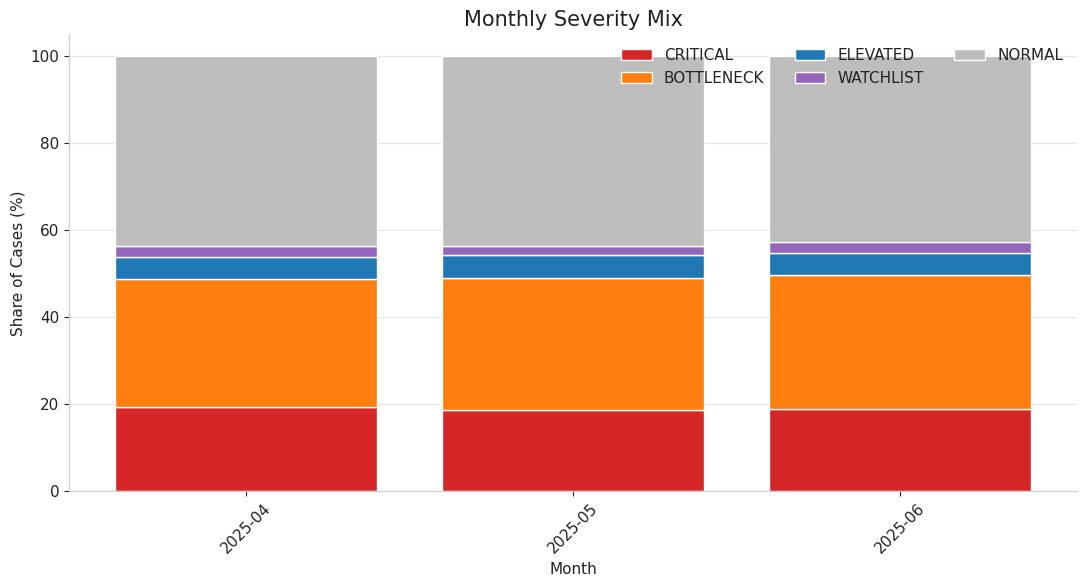

Saved: D:\logistics_AI\reports\warehouse\monitoring\warehouse_monthly_severity_mix.png


In [33]:
# CELL 13

severity_colors = {
    "CRITICAL": "#d62728",
    "BOTTLENECK": "#ff7f0e",
    "ELEVATED": "#1f77b4",
    "WATCHLIST": "#9467bd",
    "NORMAL": "#bdbdbd",
}

fig, ax = plt.subplots(figsize=(11, 6))

bottom = np.zeros(len(monthly_severity_pct_df))
x = np.arange(len(monthly_severity_pct_df.index))

for sev in severity_order:
    vals = monthly_severity_pct_df[sev].values
    ax.bar(
        x,
        vals,
        bottom=bottom,
        label=sev,
        color=severity_colors[sev],
        edgecolor="white",
    )
    bottom += vals

ax.set_title("Monthly Severity Mix")
ax.set_xlabel("Month")
ax.set_ylabel("Share of Cases (%)")
ax.set_xticks(x)
ax.set_xticklabels(monthly_severity_pct_df.index, rotation=45)
style_axes(ax, grid_axis="y")
ax.legend(frameon=False, ncol=3)

severity_mix_path = MONITORING_DIR / f"{PROCESS_KEY}_monthly_severity_mix.png"
save_and_show(fig, severity_mix_path)

In [34]:
# CELL 14

warehouse_pattern = r"PICK|PACK|STAGE|STAGING|QC|QUALITY|REWORK|PUTAWAY|SORT|ALLOC|DOCK|LOAD"

top_step_overall_df = (
    results_df[
        results_df["top_step_name"].astype(str).str.contains(warehouse_pattern, case=False, regex=True)
    ]["top_step_name"]
    .value_counts()
    .head(6)
    .reset_index()
)

if top_step_overall_df.empty:
    top_step_overall_df = (
        results_df["top_step_name"]
        .value_counts()
        .head(6)
        .reset_index()
    )

top_step_overall_df.columns = ["top_step_name", "case_count"]
top_step_list = top_step_overall_df["top_step_name"].tolist()
top_step_overall_df["step_label"] = top_step_overall_df["top_step_name"].map(pretty_step_label)

display(top_step_overall_df)

,top_step_name,case_count,step_label
0,STEP_016_STAGING_COMPLETE,565,Staging Complete
1,STEP_009_SORTATION_COMPLETE,551,Sortation Complete
2,STEP_018_LOAD_TO_TRUCK,549,Load To Truck
3,STEP_006_PICK_START,542,Pick Start
4,STEP_007_PICK_COMPLETE,538,Pick Complete
5,STEP_010_QC_COMPLETE,532,Qc Complete


In [35]:
# CELL 15

monthly_step_share_df = (
    results_df[results_df["top_step_name"].isin(top_step_list)]
    .groupby(["month", "top_step_name"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=top_step_list, fill_value=0)
)

monthly_total_cases = results_df.groupby("month")["case_id"].count()
monthly_step_share_pct_df = monthly_step_share_df.div(monthly_total_cases, axis=0) * 100

heatmap_df = monthly_step_share_pct_df.copy()
heatmap_df.columns = [pretty_step_label(c) for c in heatmap_df.columns]

display(heatmap_df)

,Staging Complete,Sortation Complete,Load To Truck,Pick Start,Pick Complete,Qc Complete
month,,,,,,
2025-04,4.495530,5.031928,4.674330,3.780332,4.086845,4.418902
2025-05,5.321454,4.599085,4.839875,4.863954,4.334216,4.815796
2025-06,4.272635,4.145473,4.196338,4.883011,5.035605,4.043744


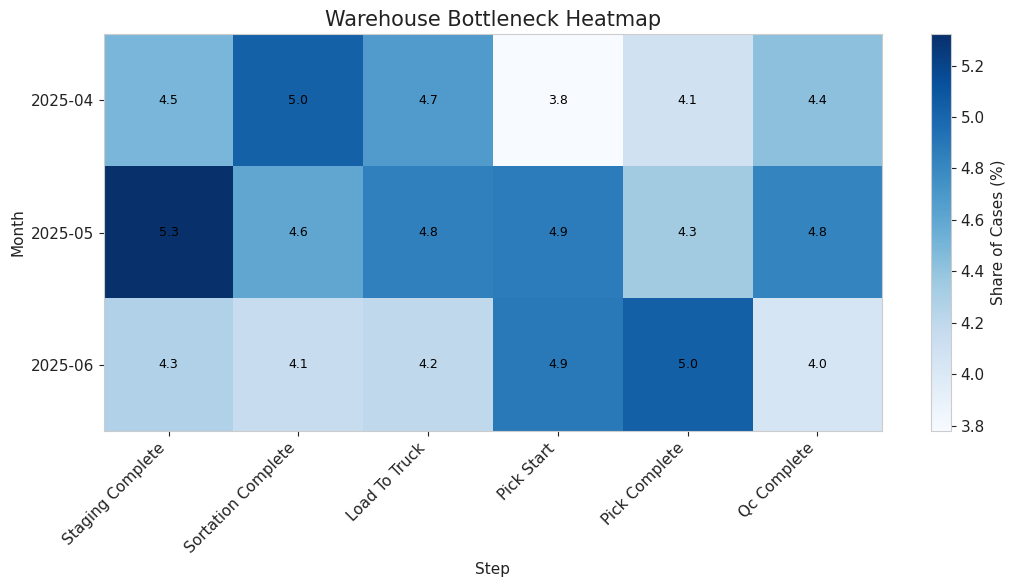

Saved: D:\logistics_AI\reports\warehouse\monitoring\warehouse_warehouse_bottleneck_heatmap.png


In [36]:
# CELL 16

fig, ax = plt.subplots(figsize=(11, 6))

im = ax.imshow(heatmap_df.values, aspect="auto", cmap="Blues")

ax.set_title("Warehouse Bottleneck Heatmap")
ax.set_xlabel("Step")
ax.set_ylabel("Month")
ax.set_xticks(np.arange(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        val = heatmap_df.iloc[i, j]
        ax.text(j, i, f"{val:.1f}", ha="center", va="center", color="black", fontsize=9)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Share of Cases (%)")

heatmap_path = MONITORING_DIR / f"{PROCESS_KEY}_warehouse_bottleneck_heatmap.png"
save_and_show(fig, heatmap_path)

In [37]:
# CELL 17

month_list = sorted(monthly_monitor_df["month"].tolist())

reference_months = month_list[:3]
recent_months = month_list[-3:]

reference_df = monthly_monitor_df[monthly_monitor_df["month"].isin(reference_months)]
recent_df = monthly_monitor_df[monthly_monitor_df["month"].isin(recent_months)]

drift_summary_df = pd.DataFrame([{
    "reference_months": ", ".join(reference_months),
    "recent_months": ", ".join(recent_months),
    "avg_risk_ref": reference_df["avg_risk"].mean(),
    "avg_risk_recent": recent_df["avg_risk"].mean(),
    "avg_risk_delta": recent_df["avg_risk"].mean() - reference_df["avg_risk"].mean(),
    "p95_risk_ref": reference_df["p95_risk"].mean(),
    "p95_risk_recent": recent_df["p95_risk"].mean(),
    "p95_risk_delta": recent_df["p95_risk"].mean() - reference_df["p95_risk"].mean(),
    "high_risk_rate_ref": reference_df["high_risk_rate"].mean(),
    "high_risk_rate_recent": recent_df["high_risk_rate"].mean(),
    "high_risk_rate_delta": recent_df["high_risk_rate"].mean() - reference_df["high_risk_rate"].mean(),
    "critical_rate_ref": reference_df["critical_rate"].mean(),
    "critical_rate_recent": recent_df["critical_rate"].mean(),
    "critical_rate_delta": recent_df["critical_rate"].mean() - reference_df["critical_rate"].mean(),
}])

display(drift_summary_df)

,reference_months,recent_months,avg_risk_ref,avg_risk_recent,avg_risk_delta,p95_risk_ref,p95_risk_recent,p95_risk_delta,high_risk_rate_ref,high_risk_rate_recent,high_risk_rate_delta,critical_rate_ref,critical_rate_recent,critical_rate_delta
0,"2025-04, 2025-05, 2025-06","2025-04, 2025-05, 2025-06",49.506892,49.506892,0.0,94.333333,94.333333,0.0,20.00735,20.00735,0.0,18.997562,18.997562,0.0


In [38]:
# CELL 18

drift_row = drift_summary_df.iloc[0]

AVG_RISK_DELTA_TRIGGER = 5.0
P95_RISK_DELTA_TRIGGER = 5.0
HIGH_RISK_RATE_DELTA_TRIGGER = 5.0
CRITICAL_RATE_DELTA_TRIGGER = 2.0   # warehouse nhạy hơn ở critical spike

trigger_df = pd.DataFrame([
    {
        "rule": "Average risk delta",
        "value": float(drift_row["avg_risk_delta"]),
        "threshold": AVG_RISK_DELTA_TRIGGER,
        "triggered": bool(drift_row["avg_risk_delta"] >= AVG_RISK_DELTA_TRIGGER),
    },
    {
        "rule": "P95 risk delta",
        "value": float(drift_row["p95_risk_delta"]),
        "threshold": P95_RISK_DELTA_TRIGGER,
        "triggered": bool(drift_row["p95_risk_delta"] >= P95_RISK_DELTA_TRIGGER),
    },
    {
        "rule": "High-risk rate delta",
        "value": float(drift_row["high_risk_rate_delta"]),
        "threshold": HIGH_RISK_RATE_DELTA_TRIGGER,
        "triggered": bool(drift_row["high_risk_rate_delta"] >= HIGH_RISK_RATE_DELTA_TRIGGER),
    },
    {
        "rule": "Critical rate delta",
        "value": float(drift_row["critical_rate_delta"]),
        "threshold": CRITICAL_RATE_DELTA_TRIGGER,
        "triggered": bool(drift_row["critical_rate_delta"] >= CRITICAL_RATE_DELTA_TRIGGER),
    },
])

display(trigger_df)

retrain_recommended = bool(trigger_df["triggered"].any())
print("Retrain recommended:", retrain_recommended)

,rule,value,threshold,triggered
0,Average risk delta,0.0,5.0,False
1,P95 risk delta,0.0,5.0,False
2,High-risk rate delta,0.0,5.0,False
3,Critical rate delta,0.0,2.0,False


Retrain recommended: False


In [39]:
# CELL 19

RUN_RETRAIN = False

RETRAIN_PARAMS = TrainParams(
    n_estimators=300,
    contamination=0.06,
    random_state=42,
)

if RUN_RETRAIN:
    retrain_result = train_process_from_key(
        PROCESS_KEY,
        params=RETRAIN_PARAMS,
        data_dir=str(DATA_DIR),
        registry_dir=str(REGISTRY_DIR),
        model_root_dir=str(MODEL_DIR),
    )
    display(pd.DataFrame([retrain_result["train_summary"]]))
else:
    print("RUN_RETRAIN = False -> retrain not executed")
    print("Suggested params:", RETRAIN_PARAMS)

RUN_RETRAIN = False -> retrain not executed
Suggested params: TrainParams(events_filename='events.csv', context_filename='cases_context.csv', include_context_numeric=False, n_estimators=300, contamination=0.06, random_state=42, allow_unknown_steps=False)


In [40]:
# CELL 20

monitoring_summary_df.to_csv(MONITORING_DIR / f"{PROCESS_KEY}_monitoring_summary.csv", index=False)
monthly_monitor_df.to_csv(MONITORING_DIR / f"{PROCESS_KEY}_monthly_monitoring.csv", index=False)
monthly_severity_pct_df.to_csv(MONITORING_DIR / f"{PROCESS_KEY}_monthly_severity_mix.csv")
heatmap_df.to_csv(MONITORING_DIR / f"{PROCESS_KEY}_monthly_bottleneck_heatmap.csv")
drift_summary_df.to_csv(MONITORING_DIR / f"{PROCESS_KEY}_drift_summary.csv", index=False)
trigger_df.to_csv(MONITORING_DIR / f"{PROCESS_KEY}_retrain_trigger_rules.csv", index=False)

generated_files = [
    MONITORING_DIR / f"{PROCESS_KEY}_monthly_risk_trend.png",
    MONITORING_DIR / f"{PROCESS_KEY}_monthly_highrisk_critical_trend.png",
    MONITORING_DIR / f"{PROCESS_KEY}_monthly_severity_mix.png",
    MONITORING_DIR / f"{PROCESS_KEY}_top_bottleneck_heatmap.png",
    MONITORING_DIR / f"{PROCESS_KEY}_monitoring_summary.csv",
    MONITORING_DIR / f"{PROCESS_KEY}_monthly_monitoring.csv",
    MONITORING_DIR / f"{PROCESS_KEY}_monthly_severity_mix.csv",
    MONITORING_DIR / f"{PROCESS_KEY}_monthly_bottleneck_heatmap.csv",
    MONITORING_DIR / f"{PROCESS_KEY}_drift_summary.csv",
    MONITORING_DIR / f"{PROCESS_KEY}_retrain_trigger_rules.csv",
]

for f in generated_files:
    print(f.exists(), "-", f)

True - D:\logistics_AI\reports\warehouse\monitoring\warehouse_monthly_risk_trend.png
True - D:\logistics_AI\reports\warehouse\monitoring\warehouse_monthly_highrisk_critical_trend.png
True - D:\logistics_AI\reports\warehouse\monitoring\warehouse_monthly_severity_mix.png
False - D:\logistics_AI\reports\warehouse\monitoring\warehouse_top_bottleneck_heatmap.png
True - D:\logistics_AI\reports\warehouse\monitoring\warehouse_monitoring_summary.csv
True - D:\logistics_AI\reports\warehouse\monitoring\warehouse_monthly_monitoring.csv
True - D:\logistics_AI\reports\warehouse\monitoring\warehouse_monthly_severity_mix.csv
True - D:\logistics_AI\reports\warehouse\monitoring\warehouse_monthly_bottleneck_heatmap.csv
True - D:\logistics_AI\reports\warehouse\monitoring\warehouse_drift_summary.csv
True - D:\logistics_AI\reports\warehouse\monitoring\warehouse_retrain_trigger_rules.csv
